# 13 - Decision Support: Uncertainty, Recourse, and Policy What-Ifs (Albania 2022)

The screener is deployable (notebook 11) and its ceiling is understood (notebooks 11-12). This notebook adds three tools that turn a probability into something a policymaker can act on, each loading a pre-computed script result:

1. **Conformal prediction** (`scripts/run_conformal.py`) - prediction *sets* with a finite-sample coverage guarantee: when is the model confident vs abstaining?
2. **Counterfactual recourse** (`scripts/run_counterfactuals.py`) - the smallest realistic change to *actionable* levers that would un-flag an at-risk student.
3. **Policy simulation** (`scripts/run_policy.py`) - population what-ifs: how far does shifting a lever nationally move the predicted at-risk rate?

All three share the headline CatBoost school-context model and PISA survey weights.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

## Part A - Conformal prediction sets: confident or abstaining?

At risk level $\alpha$ the set covers the true label with probability $\ge 1-\alpha$ (distribution-free, under exchangeability). A **singleton** set is a confident call; the **both-labels** set is the model declining to commit. Marginal and Mondrian (class-conditional) calibration, on a held-out test split, survey-weighted.

In [2]:
conf = pd.read_csv('../outputs/results/conformal_2022.csv')
conf.round(4)

,alpha,mondrian,target_coverage,coverage,avg_set_size,share_empty,share_singleton,share_ambiguous,n
0,0.05,False,0.95,0.9497,1.5569,0.0,0.4431,0.5569,1226
1,0.05,True,0.95,0.9585,1.7128,0.0,0.2872,0.7128,1226
2,0.10,False,0.90,0.9245,1.3995,0.0,0.6005,0.3995,1226
3,0.10,True,0.90,0.9190,1.5211,0.0,0.4789,0.5211,1226
4,0.20,False,0.80,0.8360,1.1157,0.0,0.8843,0.1157,1226
5,0.20,True,0.80,0.8424,1.2629,0.0,0.7371,0.2629,1226


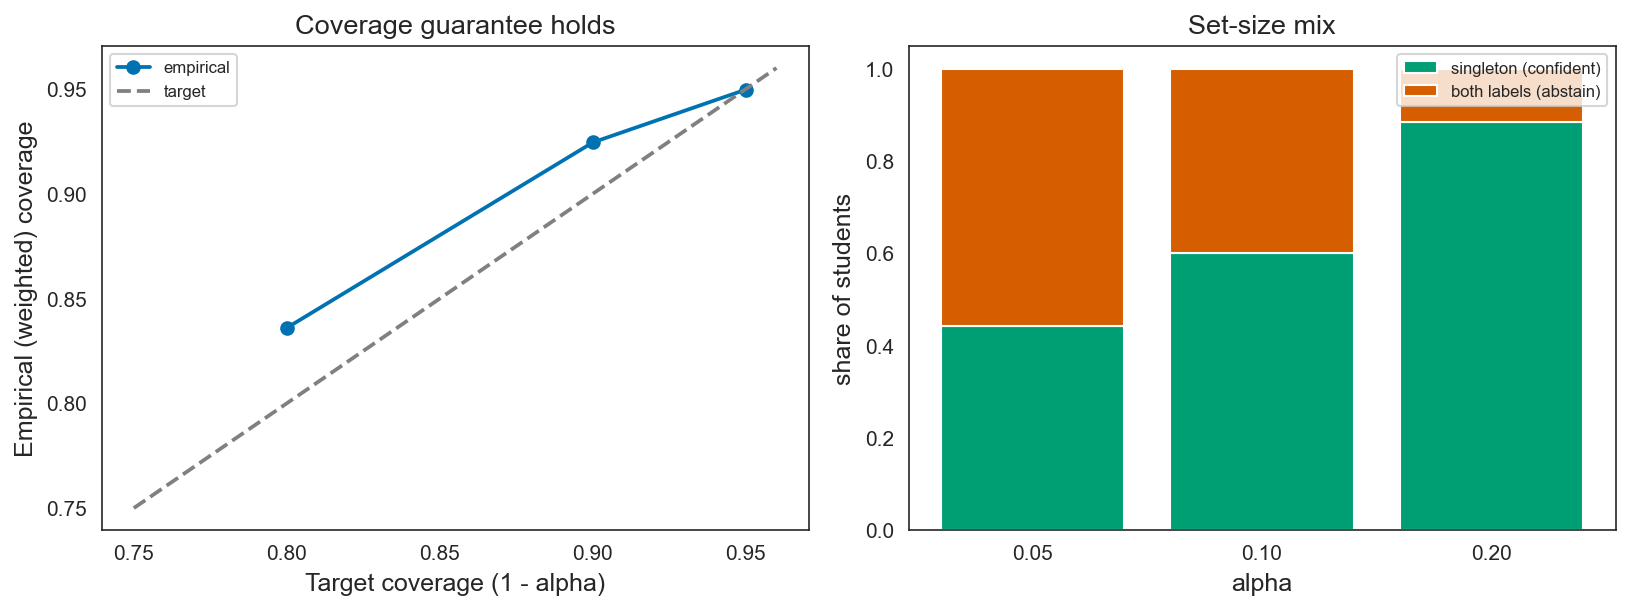

In [3]:
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
m = conf[~conf.mondrian]
fig, ax = plt.subplots(1, 2, figsize=(11,4.2))
ax[0].plot(m.target_coverage, m.coverage, '-o', color=PALETTE['blue'], label='empirical')
ax[0].plot([0.75,0.96],[0.75,0.96], ls='--', color='0.5', label='target')
ax[0].set_xlabel('Target coverage (1 - alpha)'); ax[0].set_ylabel('Empirical (weighted) coverage')
ax[0].set_title('Coverage guarantee holds'); ax[0].legend(fontsize=8)
ax[1].bar(range(len(m)), m.share_singleton, color=PALETTE['green'], label='singleton (confident)')
ax[1].bar(range(len(m)), m.share_ambiguous, bottom=m.share_singleton, color=PALETTE['vermilion'], label='both labels (abstain)')
ax[1].set_xticks(range(len(m))); ax[1].set_xticklabels([f'{a:.2f}' for a in m.alpha])
ax[1].set_xlabel('alpha'); ax[1].set_ylabel('share of students'); ax[1].set_title('Set-size mix'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading:** empirical coverage sits at or above the target at every level - the guarantee holds under survey weighting. At the 90% level the model gives a **confident singleton for ~60%** of students and **abstains (both labels) on ~40%** - an honest 'refer for human review' flag for the students where a 75%-prevalence screener is genuinely unsure. Mondrian calibration abstains more but balances coverage across the rare not-at-risk class.

## Part B - Counterfactual recourse: what would un-flag a student?

For each flagged student we search for the smallest change to *actionable* levers (anxiety down; teacher support, belonging, ICT up) that pulls predicted risk below the operating threshold. Immutable attributes (gender, immigrant status, parental education, past repetition) are held fixed.

Recourse found for 21% of flagged students (median 2 levers, 1.00 SD total)


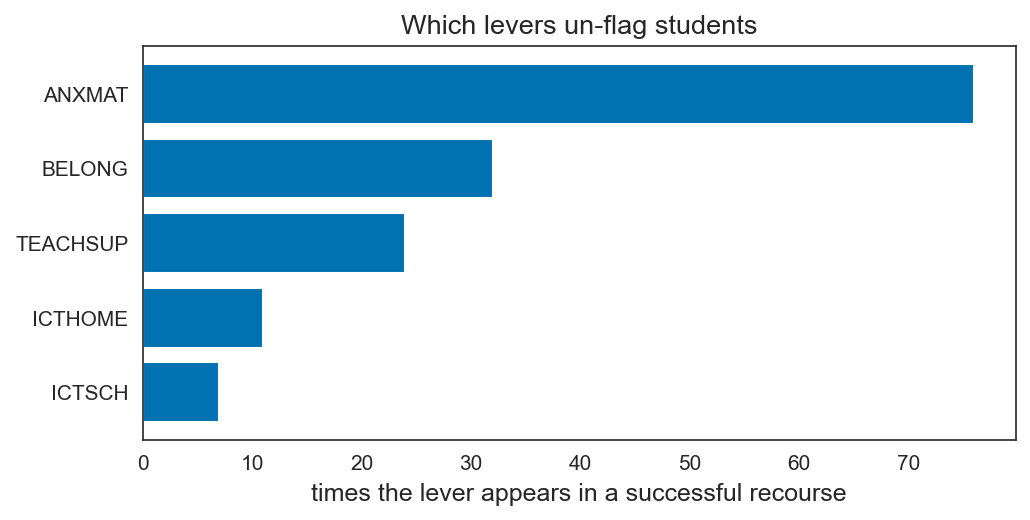

,student_idx,p_original,p_counterfactual,recourse
7,13,0.4880,0.4241,ICTHOME +0.25 SD
15,25,0.5476,0.3539,ANXMAT -0.50 SD
21,35,0.9379,0.3650,ANXMAT -1.50 SD; BELONG +1.75 SD
27,44,0.5330,0.4327,ANXMAT -0.50 SD; BELONG +0.25 SD
28,45,0.5268,0.4043,ANXMAT -0.25 SD
31,48,0.6403,0.4278,ANXMAT -1.50 SD; BELONG +0.50 SD
36,55,0.6091,0.4083,BELONG +0.25 SD; ICTSCH +1.00 SD
42,62,0.7449,0.4139,ANXMAT -1.50 SD; ICTHOME +0.25 SD


In [4]:
cf = pd.read_csv('../outputs/results/counterfactuals_2022.csv')
cfs = pd.read_csv('../outputs/results/counterfactuals_summary_2022.csv').iloc[0]
print(f"Recourse found for {cfs.recourse_rate*100:.0f}% of flagged students "
      f"(median {cfs.median_features_changed:.0f} levers, {cfs.median_cost_sd:.2f} SD total)")
succ = cf[cf.success]
from collections import Counter
lever = Counter()
for s in succ.recourse.dropna():
    for part in str(s).split(';'):
        tok = part.strip().split(' ')
        if tok and tok[0] in ('ANXMAT','TEACHSUP','BELONG','ICTHOME','ICTSCH'): lever[tok[0]] += 1
lev = pd.Series(dict(lever)).sort_values()
fig, ax = plt.subplots(figsize=(7,3.6))
ax.barh(lev.index, lev.values, color=PALETTE['blue'])
ax.set_xlabel('times the lever appears in a successful recourse'); ax.set_title('Which levers un-flag students')
plt.tight_layout(); plt.show()
succ[['student_idx','p_original','p_counterfactual','recourse']].head(8)

**Reading:** recourse via soft levers exists for only a **minority** of flagged students - the rest are too deep in structural (SES / school) risk to flip by lowering anxiety or raising support within a plausible +-3 SD budget. Where recourse *does* exist, **math anxiety is the dominant lever**, consistent with the multilevel odds ratios. This is the individual-level echo of the project's thesis: the crisis is structural, not a fine-tuning problem.

## Part C - Policy simulation: national what-ifs

Shift a lever across the whole population and re-read the weighted predicted at-risk rate. A *predictive* what-if under the model's associations, **not** a causal effect.

In [5]:
pol = pd.read_csv('../outputs/results/policy_simulation_2022.csv')
pol

,scenario,at_risk_rate,delta_at_risk_rate,delta_mean_prob
0,everything (bundle + SES + composition),0.5972,-0.1271,-0.1151
1,anxiety -1.0 SD,0.6510,-0.0733,-0.0599
2,psychosocial bundle,0.6794,-0.0448,-0.0465
3,anxiety -0.5 SD,0.6816,-0.0427,-0.0351
4,school composition +0.5 SD,0.6996,-0.0247,-0.0340
5,SES +0.5 SD,0.7114,-0.0128,-0.0183
6,teacher support +1 SD,0.7218,-0.0025,-0.0086
7,belonging +1 SD,0.7384,0.0141,0.0032


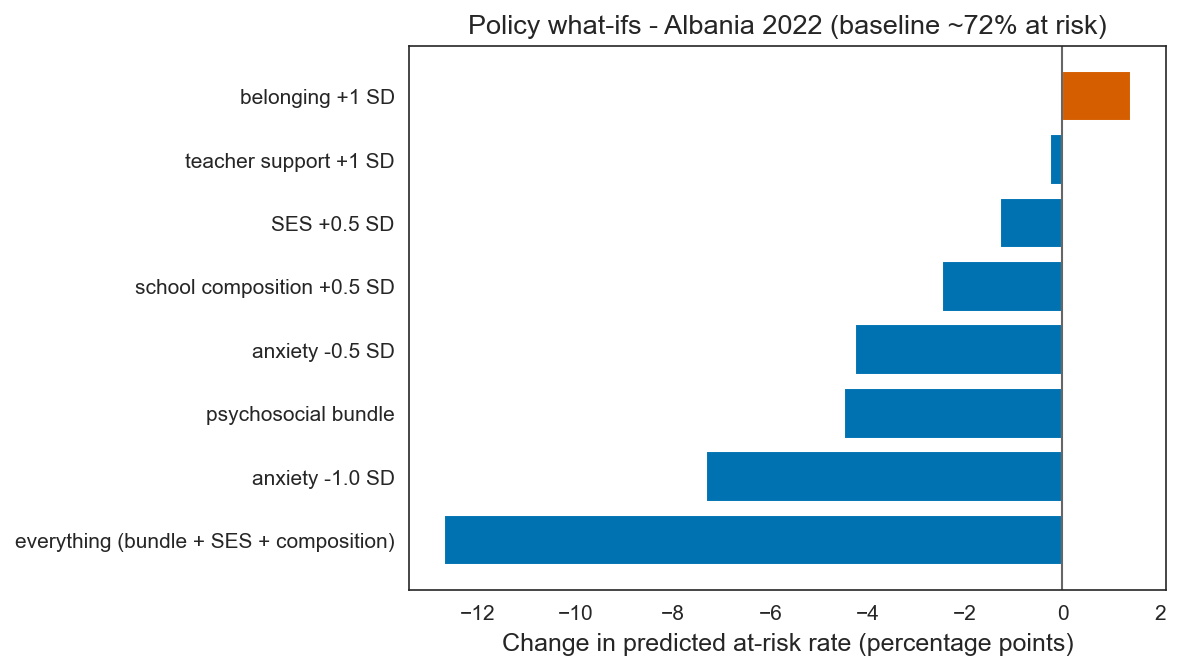

In [6]:
d = pol.sort_values('delta_at_risk_rate')
colors = [PALETTE['blue'] if v < 0 else PALETTE['vermilion'] for v in d.delta_at_risk_rate]
fig, ax = plt.subplots(figsize=(8,4.6))
ax.barh(d.scenario, d.delta_at_risk_rate*100, color=colors)
ax.axvline(0, color='0.4', lw=1)
ax.set_xlabel('Change in predicted at-risk rate (percentage points)')
ax.set_title('Policy what-ifs - Albania 2022 (baseline ~72% at risk)')
plt.tight_layout(); plt.show()

**Reading:** even the **everything-at-once** bundle (lower anxiety + more support + belonging + higher SES + lifted school composition) only cuts the predicted at-risk rate from ~72% to ~60% - a real but bounded ~12 pp. **Math anxiety is the highest-leverage single factor** (~-7 pp at -1 SD); SES and school-composition shifts help modestly; belonging moves it slightly the *wrong* way, a non-causal model association (belonging co-varies with unobserved risk here), which is exactly why the causal caveat matters. The blunt message for policy: no soft lever rescues a 75%-prevalence crisis - the gap is structural and needs system-level change.

## Conclusions & Interpretation

- **Conformal sets add an honest abstention signal.** ~60% confident singletons, ~40% 'refer for review' at 90% coverage - better than forcing a call on every student.
- **Recourse exists for a minority, and it is mostly about anxiety.** The tool is useful for the students it *can* help, and its low hit-rate is itself a finding: most risk is not individually actionable through soft levers.
- **Policy simulation quantifies the ceiling on interventions.** Aggressive population shifts buy ~12 pp; the structural core remains. Consistent with the covariate-shift, floor-effect, and school-composition results elsewhere in the project.
- **All three are model-associational, not causal.** They stress-test and communicate the fitted model; they are decision *support*, not effect estimates - read with the multilevel and school-questionnaire caveats.